# LUMINA global 21cm / 3.46cm pipeline

Linear structure, each quantity computed exactly once:

1. setup: paths, constants, cosmology
2. SED tables: BPASS stellar spectra, Shen+2020 AGN SED
3. load the global text files -> `df`
4. derived number densities + interpolants onto the snapshot grid
5. radiation field: J_alpha (stellar + AGN, H and He II)
6. couplings, spin temperatures, brightness temperatures
7. run + save

Only cell 1 holds paths. Only cell 7 writes files.


In [6]:

# =====================================================================
# 1. SETUP  —  paths, constants, cosmology
# =====================================================================
import numpy as np
import pandas as pd
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d

mpl.rcParams.update({"figure.dpi": 200, "savefig.dpi": 300,
                     "font.family": "STIXGeneral", "mathtext.fontset": "stix",
                     "font.size": 14})

# ---- paths (the only place any path appears) ------------------------
GLOBAL_DIR   = "/orcd/data/mvogelsb/004/chcho/global/"
BPASS_FILE   = "/orcd/data/mvogelsb/004/ozier/ZOOM_XL/sharedData/bpass_spectra_bin_chab100_v2.2.1.hdf5"
AGN_SED_FILE = "AGN_SED.dat"
Z_FILES      = ["Z_above4p75.csv", "Z_below4p75.csv"]   # stellar metallicity history
Z_COLUMN     = "Z_mean_mw"                              # which column of Z_FILES to use


# ---- physical constants (cgs) ---------------------------------------
PLANCK   = 6.62607015e-27     # erg s
C_LIGHT  = 2.99792458e10      # cm / s
k_B      = 1.380649e-16       # erg / K
m_p      = 1.6738e-24         # g
e_cgs    = 4.803204712570263e-10   # statC
me_cgs   = 9.1093837015e-28   # g
M_SOL    = 1.988e33           # g
YR       = 31556736.0         # s
H_eVs    = 4.13607e-15        # eV s
CMPC_CGS = 3.0857e24          # cm per cMpc

# ---- line data ------------------------------------------------------
NU_LYMAN_ALPHA    = 2.466e15      # Hz, H  Ly-alpha
NU_LYMAN_LIMIT    = 3.28984e15    # Hz, H  Lyman limit
NU_LYMAN_LIMIT_He = 1.31594e16    # Hz, He II Lyman limit (4x H)
NU_LYMAN_ALPHA_He = NU_LYMAN_LIMIT_He * (1.0 - 1.0/4.0)

LAMBDA_21cm = 21.106          # cm
LAMBDA_3cm  = 3.46            # cm
A_10        = 2.85e-15        # s^-1, H  21cm
A_10_He     = 1.959e-12       # s^-1, He II 3.46cm
T_star      = PLANCK * C_LIGHT / (k_B * LAMBDA_21cm)
T_star_He   = PLANCK * C_LIGHT / (k_B * LAMBDA_3cm)

# ---- cosmology used for H(z) and comoving densities -----------------
#      (these are the values matched to the C code / LUMINA)
OMEGA_M  = 0.30964144
OMEGA_L  = 0.6902672
H0_CGS   = 0.6766 * 100.0 * 3.241e-20     # s^-1

# ---- values that appear INSIDE the published delta-T_b prefactors ---
#      (THESAN / Kannan+2022; kept separate on purpose, do not merge)
OMEGA_B_TB, OMEGA_M_TB, H_TB = 0.0486, 0.3089, 0.6774

HYDROGEN_MASSFRAC = 0.76
y_frac            = (1.0 - HYDROGEN_MASSFRAC) / (4.0 * HYDROGEN_MASSFRAC)

# ---- box / grid for the AGN luminosity density ----------------------
N_GRID   = 640
BOX_CMPC = 500.0

def H_cgm(z):
    """Hubble parameter [1/s], flat LCDM."""
    return H0_CGS * np.sqrt(OMEGA_M * (1.0 + np.asarray(z, float))**3 + OMEGA_L)

def T_gamma(z):
    """CMB temperature [K]."""
    return 2.7255 * (1.0 + np.asarray(z, float))

# ---- recycling fractions f_rec(n), Pritchard & Furlanetto (2006) ----
_F_REC = np.array([
    0.0, 0.0, 1.0000, 0.0000, 0.2609, 0.3078, 0.3259, 0.3353, 0.3410,
    0.3448, 0.3476, 0.3496, 0.3512, 0.3524, 0.3535, 0.3543, 0.3550,
    0.3556, 0.3561, 0.3565, 0.3569, 0.3572, 0.3575, 0.3578, 0.3580,
    0.3582, 0.3584, 0.3586, 0.3587, 0.3589, 0.3590])

def f_rec(n):
    return _F_REC[n] if n < len(_F_REC) else 0.359

N_MAX = 30          # highest Lyman-series level summed

In [7]:

# =====================================================================
# 2. SED TABLES  —  BPASS stellar spectra and the AGN SED
# =====================================================================

# ---------------------------------------------------------------------
# 2a. BPASS: time-integrated photon yield N_nu(Z) [photons / Hz / baryon]
# ---------------------------------------------------------------------
with h5py.File(BPASS_FILE, "r") as f:
    _nfreq = int(f["Number_of_freq"][()])
    _nage  = int(f["N_age"][()])
    _nZ    = int(f["N_metallicity"][()])
    BPASS_FREQ = f["freq"][()]                       # Hz
    BPASS_Z    = f["metallicity"][()]                # absolute metal mass fraction
    _age       = np.maximum(f["age"][()], 1e-6)      # Gyr
    _Lnu       = f["Lnu"][()].reshape(_nZ, _nage, _nfreq)   # erg/s/Hz/Msol

# erg/s/Hz/Msol -> photons/s/Hz/baryon
_LumPhot = (_Lnu / (PLANCK * BPASS_FREQ[None, None, :])) * (m_p / M_SOL)

# age-bin widths (BPASS grid is uniform in log age, 0.1 dex)
_log_age_yr = np.log10(_age * 1e9)
_dlog       = np.median(np.diff(_log_age_yr))
_hi         = 10**(_log_age_yr + _dlog / 2)
_lo         = 10**(_log_age_yr - _dlog / 2)
_lo[0]      = 0.0                                    # first bin runs from t = 0
BPASS_DT    = (_hi - _lo) * 3.15576e7                # s

# integrate over age once, for every tabulated metallicity -> (N_Z, Nfreq)
BPASS_N_NU = np.sum(_LumPhot * BPASS_DT[None, :, None], axis=1)

print(f"BPASS: Nfreq={_nfreq}  N_age={_nage}  N_Z={_nZ}")
print("  Z grid:", np.array2string(BPASS_Z, precision=1, formatter={"float": lambda v: f"{v:.0e}"}))

def N_nu_of_Z(Z):
    """Time-integrated photon yield at a tabulated metallicity."""
    iZ = int(np.argmin(np.abs(BPASS_Z - Z)))
    return BPASS_N_NU[iZ]

_LOGZ = np.log10(BPASS_Z)

def N_nu_at(nu, Z):
    """Photon yield [photons/Hz/baryon] at frequencies nu and metallicities Z.
    nu and Z are arrays of the same length (or Z a scalar).
    Linear in log Z between BPASS grid points; Z outside the grid is set to
    the first / last grid value (1e-5 / 0.04), never extrapolated."""
    nu = np.atleast_1d(np.asarray(nu, float))
    lz = np.clip(np.log10(np.maximum(np.broadcast_to(Z, nu.shape), BPASS_Z[0])), _LOGZ[0], _LOGZ[-1])
    j  = np.clip(np.searchsorted(_LOGZ, lz) - 1, 0, len(_LOGZ) - 2)
    w  = (lz - _LOGZ[j]) / (_LOGZ[j + 1] - _LOGZ[j])
    tab = np.array([np.interp(nu, BPASS_FREQ, row) for row in BPASS_N_NU])   # (N_Z, len(nu))
    k  = np.arange(nu.size)
    return (1.0 - w) * tab[j, k] + w * tab[j + 1, k]

# diagnostic: photons per baryon in the H and He II Lyman bands.
# np.interp holds the edge value outside the table, so the table MUST cover
# the He II band (up to 54.4 eV) or the stellar He II emissivity is garbage.
assert BPASS_FREQ.max() >= NU_LYMAN_LIMIT_He, (
    f"BPASS table ends at {BPASS_FREQ.max()*H_eVs:.1f} eV < 54.4 eV: no stellar He II Lyman band")
_bH  = (BPASS_FREQ >= NU_LYMAN_ALPHA)    & (BPASS_FREQ <= NU_LYMAN_LIMIT)
_bHe = (BPASS_FREQ >= NU_LYMAN_ALPHA_He) & (BPASS_FREQ <= NU_LYMAN_LIMIT_He)
print(f"  freq = [{BPASS_FREQ.min()*H_eVs:.2f}, {BPASS_FREQ.max()*H_eVs:.1f}] eV;  "
      f"table points in H band: {_bH.sum()},  in He II band: {_bHe.sum()}")
for _Z in BPASS_Z:
    _nH  = np.trapezoid(N_nu_of_Z(_Z)[_bH],  BPASS_FREQ[_bH])
    _nHe = np.trapezoid(N_nu_of_Z(_Z)[_bHe], BPASS_FREQ[_bHe])
    print(f"  Z={_Z:.1e}  N(H Ly band) = {_nH:.4e}   N(He II Ly band) = {_nHe:.4e}   "
          f"He/H = {_nHe/_nH:.3e}  photons/baryon")

# ---------------------------------------------------------------------
# 2a'. Stellar metallicity history Z(z) from the star particles
# ---------------------------------------------------------------------
_Zt   = (pd.concat([pd.read_csv(f) for f in Z_FILES], ignore_index=True)
           .sort_values("redshift"))
Z_TAB_z = _Zt["redshift"].to_numpy(float)
Z_TAB   = np.clip(_Zt[Z_COLUMN].to_numpy(float), BPASS_Z[0], BPASS_Z[-1])   # clamp to grid

def Z_of_z(z):
    """Stellar metallicity at redshift z: linear in log Z between snapshots,
    held at the end values outside the tabulated redshift range."""
    return 10**np.interp(z, Z_TAB_z, np.log10(Z_TAB))

print("")
print(f"Z(z) from {Z_COLUMN}: {len(Z_TAB_z)} snapshots, z = {Z_TAB_z.min():.2f} .. {Z_TAB_z.max():.2f}")
print(f"  clamped to BPASS grid at {int((_Zt[Z_COLUMN] < BPASS_Z[0]).sum())} snapshots (low end), "
      f"{int((_Zt[Z_COLUMN] > BPASS_Z[-1]).sum())} (high end)")

# ---------------------------------------------------------------------
# 2b. AGN SED (Shen+2020)  —  one normalisation, one interpolant.
#     Follows AGN_Contribution.ipynb (cells 7, 11, 16) exactly.
# ---------------------------------------------------------------------
HC_EVA    = 12398.42                  # eV Angstrom
E_BOL_CUT = 5.0e5                     # eV; Shen+2020 bolometric = 30 um - 500 keV
N_FINE    = 10_000                    # fine grid for band integrals (as in the AGN note)

_d       = np.genfromtxt(AGN_SED_FILE, comments="#")
E_TAB    = HC_EVA / _d[:, 0]                          # eV
DLDE_TAB = 10**_d[:, 1] / E_TAB                       # erg/s/eV   (dL/dE = nu L_nu / E)
_o       = np.argsort(E_TAB)
E_TAB, DLDE_TAB = E_TAB[_o], DLDE_TAB[_o]

# bolometric luminosity on the native tabulated grid, E <= 500 keV
_cut   = E_TAB <= E_BOL_CUT
L_BOL  = np.trapezoid(DLDE_TAB[_cut], E_TAB[_cut])
L_FULL = np.trapezoid(DLDE_TAB, E_TAB)

# normalised shape phi(E) = (dL/dE) / L_bol  [1/eV], linear in log-log.
# EVERYTHING below (J_alpha_AGN and the band fractions) is derived from phi.
_log_phi = interp1d(np.log10(E_TAB), np.log10(DLDE_TAB / L_BOL),
                    kind="linear", bounds_error=False, fill_value="extrapolate")

def phi_E(E):
    return 10**_log_phi(np.log10(E))

def Ntilde_at(nu):
    """Photons / Hz / erg of bolometric luminosity:  (L_nu / L_bol) / (h nu)."""
    return phi_E(H_eVs * nu) * H_eVs / (PLANCK * nu)       # L_nu/L_bol = phi_E dE/dnu

E_FINE   = np.logspace(np.log10(E_TAB.min()), np.log10(E_TAB.max()), N_FINE)
PHI_FINE = phi_E(E_FINE)

def band_frac(E_lo, E_hi, exact_edges=False):
    """Fraction of L_bol (500 keV definition) emitted in [E_lo, E_hi] eV.
    exact_edges=False reproduces the AGN note (band snapped to the fine grid);
    exact_edges=True adds E_lo and E_hi as nodes (converged value)."""
    m = (E_FINE >= E_lo) & (E_FINE <= E_hi)
    if m.sum() < 2:
        raise ValueError(f"band {E_lo}-{E_hi} eV has {m.sum()} fine-grid points")
    if not exact_edges:
        return np.trapezoid(PHI_FINE[m], E_FINE[m])
    E = np.r_[E_lo, E_FINE[m], E_hi]
    return np.trapezoid(phi_E(E), E)

f_H  = band_frac(10.2, 13.6)
f_He = band_frac(40.8, 54.4)

assert E_TAB.max() >= 54.4, "AGN SED does not reach the He II Lyman limit"
_nat = lambda a, b: int(((E_TAB >= a) & (E_TAB <= b)).sum())
print("")
print(f"AGN SED: E = [{E_TAB.min():.3e}, {E_TAB.max():.3e}] eV")
print(f"  L_full = {L_FULL:.4e} erg/s   L_bol(<500 keV) = {L_BOL:.4e} erg/s   "
      f"ratio = {L_BOL/L_FULL:.4f}  (expect 0.9994)")
print(f"  Ntilde(H Ly-alpha) = {Ntilde_at(NU_LYMAN_ALPHA):.4e} ph/Hz/erg")
print(f"  f_H  = {f_H:.4e}   (expect 3.6474e-02)   exact edges: {band_frac(10.2, 13.6, True):.4e}"
      f"   native pts: {_nat(10.2, 13.6)}")
print(f"  f_He = {f_He:.4e}   (expect 9.0311e-03)   exact edges: {band_frac(40.8, 54.4, True):.4e}"
      f"   native pts: {_nat(40.8, 54.4)}")

BPASS: Nfreq=100000  N_age=34  N_Z=13
  Z grid: [1e-05 1e-04 1e-03 2e-03 3e-03 4e-03 6e-03 8e-03 1e-02 1e-02 2e-02 3e-02
 4e-02]
  freq = [0.12, 12399.6] eV;  table points in H band: 304,  in He II band: 76
  Z=1.0e-05  N(H Ly band) = 2.2003e+04   N(He II Ly band) = 9.2000e+02   He/H = 4.181e-02  photons/baryon
  Z=1.0e-04  N(H Ly band) = 2.0584e+04   N(He II Ly band) = 6.4692e+02   He/H = 3.143e-02  photons/baryon
  Z=1.0e-03  N(H Ly band) = 1.7618e+04   N(He II Ly band) = 3.3880e+02   He/H = 1.923e-02  photons/baryon
  Z=2.0e-03  N(H Ly band) = 1.6694e+04   N(He II Ly band) = 2.6262e+02   He/H = 1.573e-02  photons/baryon
  Z=3.0e-03  N(H Ly band) = 1.6240e+04   N(He II Ly band) = 2.1619e+02   He/H = 1.331e-02  photons/baryon
  Z=4.0e-03  N(H Ly band) = 1.5984e+04   N(He II Ly band) = 1.6777e+02   He/H = 1.050e-02  photons/baryon
  Z=6.0e-03  N(H Ly band) = 1.5092e+04   N(He II Ly band) = 1.1988e+02   He/H = 7.943e-03  photons/baryon
  Z=8.0e-03  N(H Ly band) = 1.4470e+04   N(He II Ly

In [9]:

# =====================================================================
# 3. LOAD  —  global text files -> df   (pure, safe to re-run)
# =====================================================================
FILES = {                        # column name : file name
    "f_HII"              : "means_HII.txt",
    "f_HeII"             : "means_HeII.txt",
    "f_HeIII"            : "means_HeIII.txt",
    "T_vol"              : "means_T.txt",
    "SFR_raw"            : "means_SFR.txt",
    "Density"            : "means_Density.txt",
    "LuminosityAGN_raw"  : "means_LuminosityAGN.txt",
    "T_neutral"          : "neutral_temp_means.txt",
    #"T_neutral_ad"       : "neutral_temp_noxray.txt",
    #"T_neutral_med"      : "neutral_temp_median.txt",
    #"T_neutral_1e-3"     : "neutral_temp_means_0.001.txt",
    #"T_neutral_med_1e-3" : "neutral_temp_median_0.001.txt",
    #"T_neutral_ad_5e-4"  : "neutral_temp_noxray_5e-4.txt",
    #"T_neutral_ad_1e-4"  : "neutral_temp_noxray_1e-4.txt",
}

# unit conversions (code units -> cgs)
SFRD_CONV    = 6.301081197556214e+25 / 1.4009476382893126e+73   # -> g/s/cm^3
AGN_LUM_CONV = 6.45e36                                          # -> erg/s per voxel
RHO_CONV     = 3.0991811197281837e-22                           # -> g/cm^3 (comoving)

def load_globals(path=GLOBAL_DIR):
    df = pd.DataFrame({"redshift": pd.read_csv(path + "redshift.txt",
                                               names=["redshift"])["redshift"]})
    for col, fname in FILES.items():
        t = pd.read_csv(path + fname, sep=r"\s+", names=["snapshot", col])
        if "snapshot" not in df:
            df.insert(0, "snapshot", t["snapshot"].astype(int))
        df[col] = t[col].values

    df["SFRD"]          = df["SFR_raw"] * SFRD_CONV
    df["LuminosityAGN"] = df["LuminosityAGN_raw"] * AGN_LUM_CONV
    return df.sort_values("redshift").reset_index(drop=True)


def add_densities(df):
    """Number densities [1/cm^3] and the HeII fraction, from the volume means."""
    z = df["redshift"]
    df["rho_H"]  = HYDROGEN_MASSFRAC * df["Density"] * RHO_CONV * (1.0 + z)**3
    df["num_H"]  = df["rho_H"] / m_p

    df["frac_HI"]   = 1.0 - df["f_HII"]
    df["num_HI"]    = df["frac_HI"]  * df["num_H"]
    df["num_HII"]   = df["f_HII"]    * df["num_H"]

    df["num_He"]    = y_frac         * df["num_H"]
    df["num_HeII"]  = df["f_HeII"]   * df["num_H"]
    df["num_HeIII"] = df["f_HeIII"]  * df["num_H"]
    df["num_HeI"]   = df["num_He"] - df["num_HeII"] - df["num_HeIII"]

    # HeII per helium nucleus (the input f_HeII is per hydrogen nucleus)
    df["x_HeII"]  = df["num_HeII"] / df["num_He"]
    df["x_HeIII"] = df["num_HeIII"] / df["num_He"]

    df["num_p"] = df["num_HII"]
    df["num_e"] = df["num_HII"] + df["num_HeII"] + 2.0 * df["num_HeIII"]

    df["T_CMB"] = T_gamma(z)
    df["H(z)"]  = H_cgm(z)
    return df


df = add_densities(load_globals())
print(f"{len(df)} snapshots, z = {df.redshift.min():.3f} .. {df.redshift.max():.3f}")
df

709 snapshots, z = 2.987 .. 29.428


,snapshot,redshift,f_HII,f_HeII,f_HeIII,T_vol,SFR_raw,Density,LuminosityAGN_raw,T_neutral,...,num_He,num_HeII,num_HeIII,num_HeI,x_HeII,x_HeIII,num_p,num_e,T_CMB,H(z)
0,708,2.986690,9.999865e-01,6.625613e-04,7.828438e-02,15954.335393,0.052337,1.348938e-09,38164.727453,NaN,...,9.495634e-07,7.969157e-09,9.415892e-07,5.099684e-12,0.008392,9.916022e-01,1.202764e-05,1.391879e-05,10.865723,9.882517e-18
1,707,2.990499,9.999864e-01,6.707433e-04,7.827620e-02,15937.080869,0.052249,1.348988e-09,37843.128349,NaN,...,9.523234e-07,8.091017e-09,9.442272e-07,5.132260e-12,0.008496,9.914985e-01,1.206260e-05,1.395914e-05,10.876106,9.896204e-18
2,706,2.994312,9.999864e-01,6.791487e-04,7.826779e-02,15919.914658,0.052154,1.349038e-09,37577.696458,NaN,...,9.550910e-07,8.216218e-09,9.468696e-07,5.164985e-12,0.008603,9.913920e-01,1.209765e-05,1.399961e-05,10.886498,9.909912e-18
3,705,2.998129,9.999863e-01,6.877846e-04,7.825916e-02,15902.907694,0.052025,1.349044e-09,38268.397872,NaN,...,9.578363e-07,8.344611e-09,9.494865e-07,5.196702e-12,0.008712,9.912826e-01,1.213243e-05,1.403974e-05,10.896901,9.923639e-18
4,704,3.001949,9.999862e-01,6.966620e-04,7.825028e-02,15886.018519,0.052042,1.349134e-09,38149.355260,NaN,...,9.606484e-07,8.477131e-09,9.521661e-07,5.236390e-12,0.008824,9.911702e-01,1.216805e-05,1.408086e-05,10.907313,9.937387e-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,4,27.624245,9.995329e-07,7.920783e-08,7.864623e-08,34.310645,0.000000,1.364558e-09,0.000000,34.310645,...,3.555403e-04,3.567132e-10,3.541841e-10,3.555395e-04,0.000001,9.961856e-07,4.501406e-09,5.566487e-09,78.015381,1.868798e-16
705,3,28.065021,9.995460e-07,7.920053e-08,7.865462e-08,34.259699,0.000000,1.364558e-09,0.000000,34.259699,...,3.722190e-04,3.734126e-10,3.708388e-10,3.722183e-04,0.000001,9.962918e-07,4.712634e-09,5.827724e-09,79.216716,1.912125e-16
706,2,28.512585,9.995593e-07,7.919313e-08,7.866312e-08,34.224915,0.000000,1.364558e-09,0.000000,34.224915,...,3.896802e-04,3.908933e-10,3.882772e-10,3.896795e-04,0.000001,9.963995e-07,4.933775e-09,6.101222e-09,80.436550,1.956457e-16
707,1,28.967040,9.995724e-07,7.918564e-08,7.867173e-08,34.205899,0.000000,1.364558e-09,0.000000,34.205899,...,4.079606e-04,4.091918e-10,4.065362e-10,4.079598e-04,0.000001,9.965086e-07,5.165291e-09,6.387555e-09,81.675168,2.001817e-16


In [54]:
"""
plt.plot(df["redshift"], df["T_vol"])
plt.plot(df["redshift"], df["T_neutral"])
plt.plot(df["redshift"], df["T_neutral_ad"])
plt.plot(df["redshift"], df["T_neutral_ad_5e-4"])
plt.plot(df["redshift"], df["T_neutral_ad_1e-4"])
#plt.plot(df["redshift"], df["T_S"])
#plt.plot(df["redshift"], df["T_S_He"])
plt.plot(df["redshift"], df["T_CMB"])
plt.xlim(30,3)
plt.yscale("log")
"""

'\nplt.plot(df["redshift"], df["T_vol"])\nplt.plot(df["redshift"], df["T_neutral"])\nplt.plot(df["redshift"], df["T_neutral_ad"])\nplt.plot(df["redshift"], df["T_neutral_ad_5e-4"])\nplt.plot(df["redshift"], df["T_neutral_ad_1e-4"])\n#plt.plot(df["redshift"], df["T_S"])\n#plt.plot(df["redshift"], df["T_S_He"])\nplt.plot(df["redshift"], df["T_CMB"])\nplt.xlim(30,3)\nplt.yscale("log")\n'

In [11]:

# =====================================================================
# 4. INTERPOLANTS  —  everything the physics reads off the z grid
# =====================================================================
Z_GRID = df["redshift"].to_numpy(float)          # ascending, set in cell 3

def _on_grid(col, fill=False):
    """np.interp against the snapshot grid for one df column."""
    y = df[col].ffill().bfill().to_numpy(float) if fill else df[col].to_numpy(float)
    return lambda z: np.interp(z, Z_GRID, y)

T_K       = _on_grid("T_neutral", fill=True)     # H  kinetic temperature
T_C       = T_K                                  # H  colour temperature
T_K_He    = _on_grid("T_vol")                    # He kinetic temperature
T_C_He    = T_K_He
n_H       = _on_grid("num_HI")
n_p       = _on_grid("num_p")
n_e       = _on_grid("num_e")
HI_frac   = _on_grid("frac_HI")
HeII_frac = _on_grid("x_HeII")
SFRD      = _on_grid("SFRD")
L_AGN     = _on_grid("LuminosityAGN")            # erg/s, mean per voxel

# ---- collisional de-excitation rates (splines built once) -----------
_T_HH = np.log10([1,2,4,6,8,10,15,20,25,30,40,50,60,70,80,90,100,
                  200,300,500,700,1000,2000,3000,5000,7000,10000])
_k_HH = np.log10([1.38e-13,1.43e-13,2.71e-13,6.60e-13,1.47e-12,2.88e-12,
                  9.10e-12,1.78e-11,2.73e-11,3.67e-11,5.38e-11,6.86e-11,
                  8.14e-11,9.25e-11,1.02e-10,1.11e-10,1.19e-10,1.75e-10,
                  2.09e-10,2.56e-10,2.91e-10,3.31e-10,4.27e-10,4.97e-10,
                  6.03e-10,6.87e-10,7.87e-10])
_T_eH = np.log10([1,2,5,10,20,50,100,200,500,1000,2000,3000,5000,7000,
                  10000,15000,20000])
_k_eH = np.log10([2.39e-10,3.37e-10,5.30e-10,7.46e-10,1.05e-9,1.63e-9,
                  2.26e-9,3.11e-9,4.59e-9,5.92e-9,7.15e-9,7.71e-9,
                  8.17e-9,8.32e-9,8.37e-9,8.29e-9,8.11e-9])
_k_pH = np.log10([0.40e-9,0.45e-9,0.430e-9,0.369e-9,0.317e-9,0.3047e-9,
                  0.3379e-9,0.4043e-9,0.5471e-9,0.7051e-9,0.9167e-9,
                  1.070e-9,1.301e-9,1.480e-9,1.695e-9,1.975e-9,2.201e-9])

_S_HH, _S_eH, _S_pH = (CubicSpline(_T_HH, _k_HH),
                       CubicSpline(_T_eH, _k_eH),
                       CubicSpline(_T_eH, _k_pH))

kappa_HH = lambda T: 10.0**_S_HH(np.log10(T))
kappa_eH = lambda T: 10.0**_S_eH(np.log10(T))
kappa_pH = lambda T: 10.0**_S_pH(np.log10(T))

In [16]:

# =====================================================================
# 5. RADIATION FIELD  —  J_alpha from stars and from AGN
# =====================================================================
import time
# One Lyman-series sum serves all four cases (stars/AGN x H/He II).
# The two sources differ only in the emissivity and the z' sampling.

def J_lyman(z_target, nu_limit, emissivity, z_nodes, n_max=N_MAX):
    """Background intensity at Lyman-alpha [photons / s / cm^2 / Hz / sr].

    emissivity(nu, z) -> photons / s / Hz / cm^3
    z_nodes(z_target, z_max) -> the z' grid the integral is evaluated on
    """
    total = 0.0
    for n in range(2, n_max + 1):
        fr = f_rec(n)
        if fr == 0.0:
            continue
        zmx = (1.0 + z_target) * (1.0 - (n + 1.0)**-2.0) / (1.0 - n**-2.0) - 1.0
        if zmx <= z_target:
            continue
        zv = z_nodes(z_target, zmx)
        if zv.size < 2:
            continue
        nu_e = nu_limit * (1.0 - n**-2.0) * (1.0 + zv) / (1.0 + z_target)
        total += fr * np.trapezoid(C_LIGHT / H_cgm(zv) * emissivity(nu_e, zv), zv)
    return total * (1.0 + z_target)**2 / (4.0 * np.pi)


# ---- z' sampling ----------------------------------------------------
# Every source is integrated on the same fine grid from z to z_max(n).
# (Using the snapshot redshifts as nodes, as before, cut each window at the
#  last snapshot below z_max and dropped the high-n windows entirely once they
#  became narrower than the snapshot spacing: 3-12% of the stellar J_alpha.)
Z_NSTEPS    = 300
_nodes_fine = lambda zt, zmx: np.linspace(zt, zmx, Z_NSTEPS)
_nodes_snap = lambda zt, zmx: Z_GRID[(Z_GRID >= zt) & (Z_GRID <= zmx)]   # old scheme, for comparison only

# ---- emissivities ---------------------------------------------------
V_VOXEL = (BOX_CMPC * CMPC_CGS / N_GRID)**3        # comoving cm^3

def make_eps_stellar(Z_spec):
    """Stellar emissivity [photons/s/Hz/cm^3].
    Z_spec is either a number (fixed metallicity) or a function Z(z).
    Z is evaluated at the EMISSION redshift z', i.e. per node of the integral."""
    Zf = Z_spec if callable(Z_spec) else (lambda zz: Z_spec)
    return lambda nu, z: N_nu_at(nu, Zf(z)) * SFRD(z) / m_p

def eps_agn(nu, z):
    return Ntilde_at(nu) * L_AGN(z) / V_VOXEL


# ---- the four J_alpha arrays over the whole grid ---------------------
def compute_J(zs, Z_spec=Z_of_z, include_stellar_He=True, verbose=True):
    """Returns a dict of J_alpha arrays, each evaluated once per redshift.
    Z_spec: Z(z) from the star particles by default; pass a number for a fixed Z.
    Z is evaluated inside, at each emission redshift z' (see make_eps_stellar)."""
    eps_star = make_eps_stellar(Z_spec)

    Zf = Z_spec if callable(Z_spec) else (lambda zz: Z_spec)
    N  = len(zs)
    J  = {k: np.empty(N) for k in
          ("J_alpha_star", "J_alpha_AGN", "J_alpha_star_He", "J_alpha_AGN_He")}

    if verbose:
        Zlab = "Z(z)" if callable(Z_spec) else f"Z = {Z_spec:.1e}"
        print(f"compute_J: {N} redshifts, {Zlab}, "
              f"He II stellar term {'ON' if include_stellar_He else 'OFF'}")
        print(f"{'i':>5} {'z':>8} {'Z(z)':>10} {'J_star':>11} {'J_AGN':>11} "
              f"{'J_star_He':>11} {'J_AGN_He':>11} {'AGN/tot':>8} {'t[s]':>6}")
    t0 = time.time()

    for i, z in enumerate(zs):
        J["J_alpha_star"][i]    = J_lyman(z, NU_LYMAN_LIMIT,    eps_star, _nodes_fine)
        J["J_alpha_AGN"][i]     = J_lyman(z, NU_LYMAN_LIMIT,    eps_agn,  _nodes_fine)
        J["J_alpha_AGN_He"][i]  = J_lyman(z, NU_LYMAN_LIMIT_He, eps_agn,  _nodes_fine)
        J["J_alpha_star_He"][i] = (J_lyman(z, NU_LYMAN_LIMIT_He, eps_star, _nodes_fine)
                                   if include_stellar_He else 0.0)
        if verbose:
            row  = [J[k][i] for k in ("J_alpha_star", "J_alpha_AGN",
                                      "J_alpha_star_He", "J_alpha_AGN_He")]
            tot  = row[0] + row[1]
            bad  = (not np.all(np.isfinite(row))) or min(row) < 0.0
            print(f"{i:5d} {z:8.4f} {float(Zf(z)):10.3e} "
                  + " ".join(f"{v:11.4e}" for v in row)
                  + f" {row[1] / tot if tot > 0 else 0.0:8.3f} {time.time() - t0:6.1f}"
                  + ("   <-- CHECK: NaN/inf/negative" if bad else ""), flush=True)

    J["J_alpha"]    = J["J_alpha_star"] + J["J_alpha_AGN"]
    J["J_alpha_He"] = J["J_alpha_star_He"] + J["J_alpha_AGN_He"] #0 # to remove the contribution
    return J

In [17]:

# =====================================================================
# 6. COUPLINGS AND TEMPERATURES  —  all vectorised over z
# =====================================================================
F_ALPHA = 0.4162          # Ly-alpha oscillator strength

def compute_temperatures(z, J):
    """Given the J_alpha arrays, return every derived column. No recursion:
    each quantity is evaluated once and reused by the ones below it."""
    o   = {}
    Tg  = T_gamma(z)
    Tk  = T_K(z)
    TkH = T_K_He(z)

    # ---- Wouthuysen-Field suppression --------------------------------
    o["tau_GP"]      = 3.0e5 * HI_frac(z)   * ((1.0 + z) / 7.0)**1.5
    o["tau_GP_He"]   = 6.0e3 * HeII_frac(z) * ((1.0 + z) / 7.0)**1.5
    o["S_alpha"]     = np.exp(-0.803 * Tk**(-2.0/3.0)  * (1e-6 * o["tau_GP"])**(1.0/3.0))
    o["S_alpha_He"]  = np.exp(-0.803 * TkH**(-2.0/3.0) * (1e-6 * o["tau_GP_He"])**(1.0/3.0))

    # ---- Lyman-alpha coupling ----------------------------------------
    pre_H  = (16.0 * np.pi**2 * T_star    * e_cgs**2 * F_ALPHA) / (27.0 * A_10    * Tg * me_cgs * C_LIGHT)
    pre_He = (16.0 * np.pi**2 * T_star_He * e_cgs**2 * F_ALPHA) / ( 9.0 * A_10_He * Tg * me_cgs * C_LIGHT)
    o["x_a"]    = pre_H  * o["S_alpha"]    * J["J_alpha"]
    o["x_a_He"] = pre_He * o["S_alpha_He"] * J["J_alpha_He"]

    # ---- collisional coupling ----------------------------------------
    o["x_c"] = T_star * (kappa_HH(Tk) * n_H(z) + kappa_eH(Tk) * n_e(z)
                         + kappa_pH(Tk) * n_p(z)) / (A_10 * Tg)

    a_0       = 5.29177e-9                       # cm, Bohr radius
    bar_sigma = (2.291112e-11 / (k_B * TkH)) * a_0**2      # 14.3 eV / kT * a0^2
    kappa_He  = n_e(z) * np.sqrt(8.0 * k_B * TkH / (np.pi * me_cgs * C_LIGHT**2)) * C_LIGHT * bar_sigma
    o["x_c_He"] = T_star_He * kappa_He / (A_10_He * Tg)

    # ---- spin temperatures -------------------------------------------
    o["T_S"]    = ((1.0 + o["x_a"] + o["x_c"]) /
                   (1.0/Tg + o["x_a"]/T_C(z) + o["x_c"]/Tk))
    o["T_S_He"] = ((1.0 + o["x_a_He"] + o["x_c_He"]) /
                   (1.0/Tg + o["x_a_He"]/T_C_He(z) + o["x_c_He"]/TkH))

    # ---- brightness temperatures -------------------------------------
    sat_H  = 1.0 - Tg / o["T_S"]
    sat_He = 1.0 - Tg / o["T_S_He"]
    geom   = np.sqrt((0.15 * (1.0 + z)) / (OMEGA_M_TB * H_TB**2 * 10.0))
    ob     = OMEGA_B_TB * H_TB**2 / 0.023

    o["T_b"]        = 27.0   * HI_frac(z)   * ob * geom * sat_H          # mK
    o["T_b_He"]     = 1.67   * HeII_frac(z) * ob * geom * sat_He         # uK
    o["T_b_He_S26"] = 0.58   * HeII_frac(z) * (1.0 + z)**2 * (H0_CGS / H_cgm(z)) * sat_He
    o["T_b_He_K20"] = 0.5106 * HeII_frac(z) * ob * np.sqrt(0.24 * (1.0 + z) / OMEGA_M_TB) * sat_He
    o["T_b_He_F08"] = 0.53   * HeII_frac(z) * (1.0 + z)**0.5 * sat_He
    return o


def report_steps(z, J, o):
    """One line per redshift with the quantities that feed delta-T_b.
    Flags rows that violate a physical requirement:
      - any NaN / inf
      - x_HI or x_HeII outside [0, 1]
      - x_a, x_c < 0
      - T_S not between T_gamma and T_K (T_C = T_K here, so T_S must lie between them)"""
    Tg, Tk, TkH = T_gamma(z), T_K(z), T_K_He(z)
    xHI, xHeII  = HI_frac(z), HeII_frac(z)

    def between(T, a, b):
        lo, hi = np.minimum(a, b), np.maximum(a, b)
        return (T >= lo * (1 - 1e-6)) & (T <= hi * (1 + 1e-6))

    checks = {
        "nan":   ~np.isfinite(np.c_[o["x_a"], o["x_c"], o["T_S"], o["T_b"],
                                    o["x_a_He"], o["x_c_He"], o["T_S_He"], o["T_b_He"]]).all(axis=1),
        "xHI":   (xHI < 0) | (xHI > 1),
        "xHeII": (xHeII < 0) | (xHeII > 1),
        "x<0":   (o["x_a"] < 0) | (o["x_c"] < 0) | (o["x_a_He"] < 0) | (o["x_c_He"] < 0),
        "T_S":   ~between(o["T_S"], Tg, Tk),
        "T_S_He": ~between(o["T_S_He"], Tg, TkH),
    }

    print(f"\n{'i':>5} {'z':>8} | {'x_HI':>7} {'T_K':>9} {'x_a':>10} {'x_c':>10} "
          f"{'T_S':>9} {'T_b[mK]':>9} | {'x_HeII':>8} {'T_K_He':>9} {'x_a_He':>10} "
          f"{'x_c_He':>10} {'T_S_He':>9} {'T_b_He[uK]':>10}")
    for i in range(len(z)):
        flags = [k for k, v in checks.items() if v[i]]
        print(f"{i:5d} {z[i]:8.4f} | {xHI[i]:7.4f} {Tk[i]:9.3e} {o['x_a'][i]:10.3e} "
              f"{o['x_c'][i]:10.3e} {o['T_S'][i]:9.3e} {o['T_b'][i]:9.3f} | "
              f"{xHeII[i]:8.4f} {TkH[i]:9.3e} {o['x_a_He'][i]:10.3e} {o['x_c_He'][i]:10.3e} "
              f"{o['T_S_He'][i]:9.3e} {o['T_b_He'][i]:10.4f}"
              + (f"   <-- CHECK: {', '.join(flags)}" if flags else ""))

    nbad = {k: int(v.sum()) for k, v in checks.items() if v.any()}
    print(f"\n{len(z)} redshifts checked: " + ("all OK" if not nbad else f"flagged {nbad}"))
    return nbad

In [19]:

# =====================================================================
# 7. RUN  —  then save
# =====================================================================
z = df["redshift"].to_numpy(float)

J   = compute_J(z)                      # Z(z) used inside; prints one line per redshift
out = compute_temperatures(z, J)
report_steps(z, J, out)                 # prints one line per redshift + flags

df["Z_star"] = Z_of_z(z)                # record only; not used in the calculation
for name, arr in {**J, **out}.items():
    df[name] = arr

#df.to_csv("LUMINA_ALL.csv", index=False)

compute_J: 709 redshifts, Z(z), He II stellar term ON
    i        z       Z(z)      J_star       J_AGN   J_star_He    J_AGN_He  AGN/tot   t[s]
    0   2.9867  1.599e-02  6.0474e-09  1.0854e-10  6.1881e-12  1.8355e-12    0.018    0.0
    1   2.9905  1.599e-02  6.0458e-09  1.0843e-10  6.1914e-12  1.8338e-12    0.018    0.0
    2   2.9943  1.599e-02  6.0442e-09  1.0834e-10  6.1951e-12  1.8323e-12    0.018    0.1
    3   2.9981  1.599e-02  6.0426e-09  1.0825e-10  6.1988e-12  1.8307e-12    0.018    0.1
    4   3.0019  1.598e-02  6.0412e-09  1.0811e-10  6.2027e-12  1.8286e-12    0.018    0.1
    5   3.0058  1.596e-02  6.0395e-09  1.0797e-10  6.2063e-12  1.8264e-12    0.018    0.1
    6   3.0096  1.595e-02  6.0379e-09  1.0786e-10  6.2099e-12  1.8245e-12    0.018    0.1
    7   3.0134  1.593e-02  6.0363e-09  1.0774e-10  6.2135e-12  1.8227e-12    0.018    0.1
    8   3.0173  1.592e-02  6.0346e-09  1.0763e-10  6.2169e-12  1.8208e-12    0.018    0.2
    9   3.0211  1.590e-02  6.0329e-09  1.0750e

In [8]:

# =====================================================================
# 8. METALLICITY SWEEP  —  one CSV per BPASS metallicity
# =====================================================================
base = df.copy()
z    = base["redshift"].to_numpy(float)

# the AGN terms do not depend on Z, so compute them once
J_agn = {k: compute_J(z, BPASS_Z[0], verbose=False)[k]
         for k in ("J_alpha_AGN", "J_alpha_AGN_He")}

for Z_metal in BPASS_Z:
    eps_star = make_eps_stellar(Z_metal)
    J = dict(J_agn)
    J["J_alpha_star"]    = np.array([J_lyman(zi, NU_LYMAN_LIMIT,    eps_star, _nodes_fine) for zi in z])
    J["J_alpha_star_He"] = np.array([J_lyman(zi, NU_LYMAN_LIMIT_He, eps_star, _nodes_fine) for zi in z])
    J["J_alpha"]         = J["J_alpha_star"] + J["J_alpha_AGN"]
    J["J_alpha_He"]      = J["J_alpha_star_He"] + J["J_alpha_AGN_He"]

    out = compute_temperatures(z, J)
    d = base.copy()
    for name, arr in {**J, **out}.items():
        d[name] = arr

    fname = f"LUMINA_ALL_Z_{Z_metal:.1e}.csv"
    #d.to_csv(fname, index=False)
    nonfinite = int((~np.isfinite(out["T_b"])).sum() + (~np.isfinite(out["T_b_He"])).sum())
    print(f"Z = {Z_metal:.1e}   J_star(z_min) = {J['J_alpha_star'][0]:.3e}   "
          f"T_b(z_min) = {out['T_b'][0]:.3f} mK   non-finite T_b: {nonfinite}   -> {fname}",
          flush=True)

Z = 1.0e-05   J_star(z_min) = 1.023e-08   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_1.0e-05.csv
Z = 1.0e-04   J_star(z_min) = 9.566e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_1.0e-04.csv
Z = 1.0e-03   J_star(z_min) = 8.206e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_1.0e-03.csv
Z = 2.0e-03   J_star(z_min) = 7.788e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_2.0e-03.csv
Z = 3.0e-03   J_star(z_min) = 7.564e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_3.0e-03.csv
Z = 4.0e-03   J_star(z_min) = 7.449e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_4.0e-03.csv
Z = 6.0e-03   J_star(z_min) = 7.069e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_6.0e-03.csv
Z = 8.0e-03   J_star(z_min) = 6.768e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   -> LUMINA_ALL_Z_8.0e-03.csv
Z = 1.0e-02   J_star(z_min) = 6.597e-09   T_b(z_min) = 0.000 mK   non-finite T_b: 0   ->

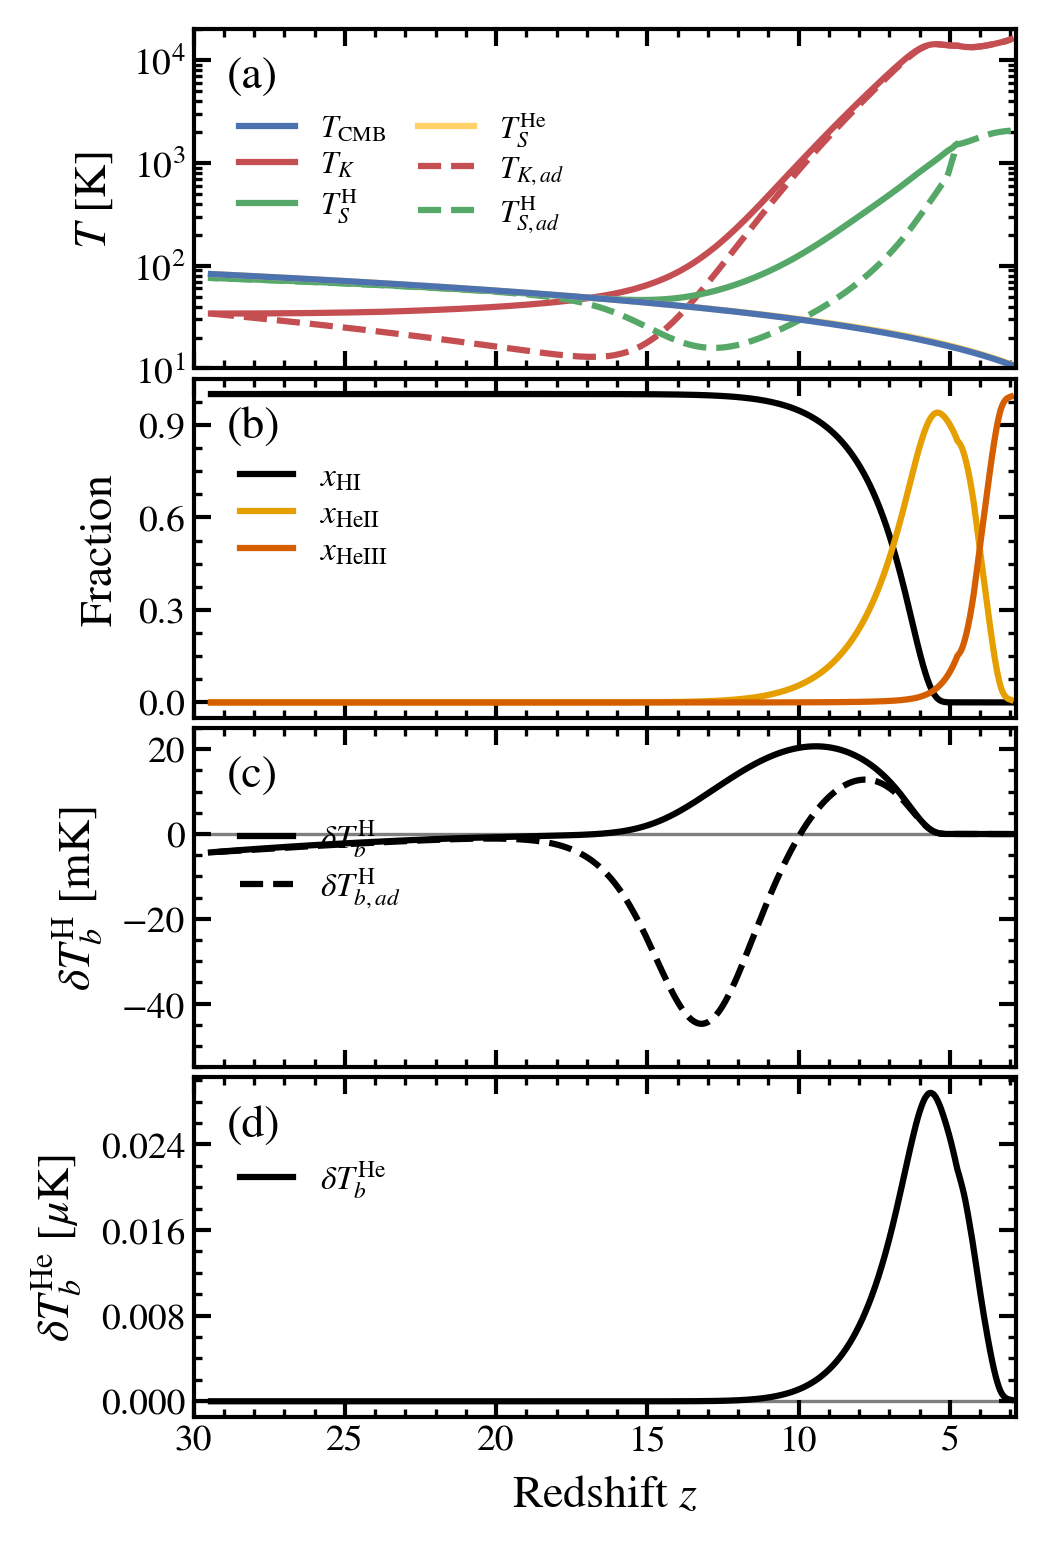

In [21]:

# =====================================================================
# 9. SUMMARY FIGURE  —  single column, 4 panels (publication style)
# =====================================================================
import os
from matplotlib.ticker import MaxNLocator

STYLE = {
    "font.size": 9, "axes.labelsize": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0, "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8, "ytick.minor.width": 0.8,
    "xtick.major.size": 4, "ytick.major.size": 4, "xtick.minor.size": 2,
    "legend.frameon": False, "legend.handlelength": 1.7,
    "figure.dpi": 300, "savefig.dpi": 600,
    "pdf.fonttype": 42, "ps.fonttype": 42,
}

AD_TS_FILE     = "LUMINA_ALL_ad.csv"   # adiabatic comparison: T_S, T_b   (skipped if absent)
AD_TK_FILE     = "temp_ad.csv"        # adiabatic comparison: T_K        (skipped if absent)
MASK_FILLED_TS = True                 # hide T_S where T_neutral was gap-filled (z < ~4.8)

c_cmb, c_tk, c_ts, c_ts_He = "#4C72B0", "#C44E52", "#55A868", "#ffd166"
c_xHI, c_tb, c_he          = "black", "black", "black"
c_xHeII, c_xHeIII          = "#E69F00", "#D55E00"
lw = 1.5

ad   = pd.read_csv(AD_TS_FILE) if os.path.exists(AD_TS_FILE) else None
ad_T = pd.read_csv(AD_TK_FILE) if os.path.exists(AD_TK_FILE) else None

zz  = df["redshift"]
T_S = df["T_S"].where(df["T_neutral"].notna()) if MASK_FILLED_TS else df["T_S"]

leg  = dict(loc="center left", fontsize=8, handlelength=1.6, borderpad=0.15, labelspacing=0.2)
zero = dict(y=0, linestyle="-", color="black", linewidth=0.8, alpha=0.5)

with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(4, 1, figsize=(3.45, 5.0), sharex=True)

    # ---- (a) temperatures ------------------------------------------------
    ax = axes[0]
    ax.plot(zz, df["T_vol"], color=c_tk, lw=lw, label=r"$T_K$")
    if ad_T is not None:
        ax.plot(ad_T["redshift"], ad_T["T_vol"], color=c_tk, ls="--", lw=lw, label=r"$T_{K, ad}$")
    ax.plot(zz, T_S, color=c_ts, lw=lw, label=r"$T^\mathrm{H}_S$")
    if ad is not None:
        ax.plot(ad["redshift"], ad["T_S"], color=c_ts, ls="--", lw=lw, label=r"$T^\mathrm{H}_{S, ad}$")
    ax.plot(zz, df["T_S_He"], color=c_ts_He, lw=lw, label=r"$T^{\mathrm{He}}_S$")
    ax.plot(zz, df["T_CMB"],  color=c_cmb,   lw=lw, label=r"$T_{\rm CMB}$")
    ax.set_ylabel(r"$T\ [{\rm K}]$")
    ax.set_yscale("log")
    ax.set_ylim(1e1, 2e4)

    # 2-column legend: CMB, T_K, T_S^H | T_S^He, T_K,ad, T_S,ad
    h, l  = ax.get_legend_handles_labels()
    order = [r"$T_{\rm CMB}$", r"$T_K$", r"$T^\mathrm{H}_S$", r"$T^{\mathrm{He}}_S$",
             r"$T_{K, ad}$", r"$T^\mathrm{H}_{S, ad}$"]
    idx   = [l.index(s) for s in order if s in l]
    ax.legend([h[i] for i in idx], [l[i] for i in idx], ncol=2, loc="center left",
              bbox_to_anchor=(0.03, 0.58), fontsize=7.5, handlelength=1.8,
              columnspacing=1.0, borderpad=0.15, labelspacing=0.2)

    # ---- (b) ionisation fractions ----------------------------------------
    ax = axes[1]
    ax.plot(zz, 1.0 - df["f_HII"], color=c_xHI,    lw=lw, label=r"$x_{\rm HI}$")
    ax.plot(zz, df["x_HeII"],      color=c_xHeII,  lw=lw, label=r"$x_{\rm HeII}$")    # per He nucleus
    ax.plot(zz, df["x_HeIII"],     color=c_xHeIII, lw=lw, label=r"$x_{\rm HeIII}$")
    ax.set_ylabel("Fraction")
    ax.legend(bbox_to_anchor=(0.03, 0.60), **leg)

    # ---- (c) HI 21cm -----------------------------------------------------
    ax = axes[2]
    ax.plot(zz, df["T_b"], color=c_tb, lw=lw, label=r"$\delta T_b^{\rm H}$")
    if ad is not None:
        ax.plot(ad["redshift"], ad["T_b"], color=c_tb, ls="--", lw=lw, label=r"$\delta T_{b, ad}^{\rm H}$")
    ax.axhline(**zero)
    ax.set_ylabel(r"$\delta T_b^{\rm H}\ [{\rm mK}]$")
    ax.set_ylim(-55, 25)
    ax.legend(bbox_to_anchor=(0.03, 0.60), **leg)

    # ---- (d) 3He+ 3.46cm -------------------------------------------------
    ax = axes[3]
    ax.plot(zz, df["T_b_He"], color=c_he, lw=lw, label=r"$\delta T_b^{\rm He}$")
    ax.axhline(**zero)
    ax.set_ylabel(r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$")
    ax.set_xlabel(r"Redshift $z$")
    ax.legend(bbox_to_anchor=(0.03, 0.70), **leg)

    # ---- shared formatting -------------------------------------------------
    for i, (ax, lab) in enumerate(zip(axes, ["(a)", "(b)", "(c)", "(d)"])):
        ax.set_xlim(2.8, 30)
        ax.tick_params(which="both", direction="in", top=True, right=True, pad=2)
        ax.minorticks_on()
        if i != 0:
            ax.yaxis.set_major_locator(MaxNLocator(4))
        if i < 3:
            ax.tick_params(labelbottom=False)
        ax.text(0.040, 0.92, lab, transform=ax.transAxes, fontsize=11, ha="left", va="top")
    axes[-1].invert_xaxis()

    fig.subplots_adjust(left=0.19, right=0.985, bottom=0.07, top=0.995, hspace=0.03)
    # plt.savefig("global_4panel_singlecolumn.pdf", bbox_inches="tight")
    plt.show()

In [20]:
"""
# Writes Z_history.txt (redshift, Z) for compute_Jalpha(_He).c from the star-particle tables.
import numpy as np, pandas as pd
t = pd.concat([pd.read_csv("Z_above4p75.csv"), pd.read_csv("Z_below4p75.csv")]).sort_values("redshift")
np.savetxt("Z_history.txt", np.c_[t["redshift"], t["Z_mean_mw"]], fmt="%.10e",
           header="redshift  Z_mean_mw  (stellar mass-weighted metallicity; clamped to the BPASS grid inside the C code)")
print(f"wrote Z_history.txt: {len(t)} rows, z = {t.redshift.min():.3f} .. {t.redshift.max():.3f}")
"""

'\n# Writes Z_history.txt (redshift, Z) for compute_Jalpha(_He).c from the star-particle tables.\nimport numpy as np, pandas as pd\nt = pd.concat([pd.read_csv("Z_above4p75.csv"), pd.read_csv("Z_below4p75.csv")]).sort_values("redshift")\nnp.savetxt("Z_history.txt", np.c_[t["redshift"], t["Z_mean_mw"]], fmt="%.10e",\n           header="redshift  Z_mean_mw  (stellar mass-weighted metallicity; clamped to the BPASS grid inside the C code)")\nprint(f"wrote Z_history.txt: {len(t)} rows, z = {t.redshift.min():.3f} .. {t.redshift.max():.3f}")\n'

In [10]:
df.to_csv("LUMINA_ALL_Coll_only.csv", index=False)